<a href="https://colab.research.google.com/github/mmuputisi/Adv-Py_Data_Analysis/blob/main/Moving%20average%20Aggregate%20ESG%20regression%20model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

MOVING AVERAGE ESG MODEL ANALYSIS

Models to be estimated:
1. Simple Lag (t-1 only)
2. Moving Average 1-2 years (avg of t-1 and t-2)
3. Moving Average 1-3 years (avg of t-1, t-2, t-3)
4. Moving Average 1-4 years (avg of t-1 through t-4)
5. Moving Average 1-5 years (avg of t-1 through t-5)

MOVING AVERAGE ESG MODEL ANALYSIS
Loading and preparing data...
✓ Created aggregate ESG score from E, S, G components
✓ Total observations: 388
✓ Consumer Staples: 80 observations
✓ All sectors: 388 observations

MODEL: Simple Lag (t-1)

--- Consumer Staples Only ---
Observations: 72
Firms: 8
Error running model: 'WaldTestStatistic' object has no attribute 'df_num'

--- All Sectors ---
Observations: 348
Firms: 40
Error running model: 'WaldTestStatistic' object has no attribute 'df_num'

MODEL: Moving Average 2 years (t-1 to t-2)

--- Consumer Staples Only ---
Observations:

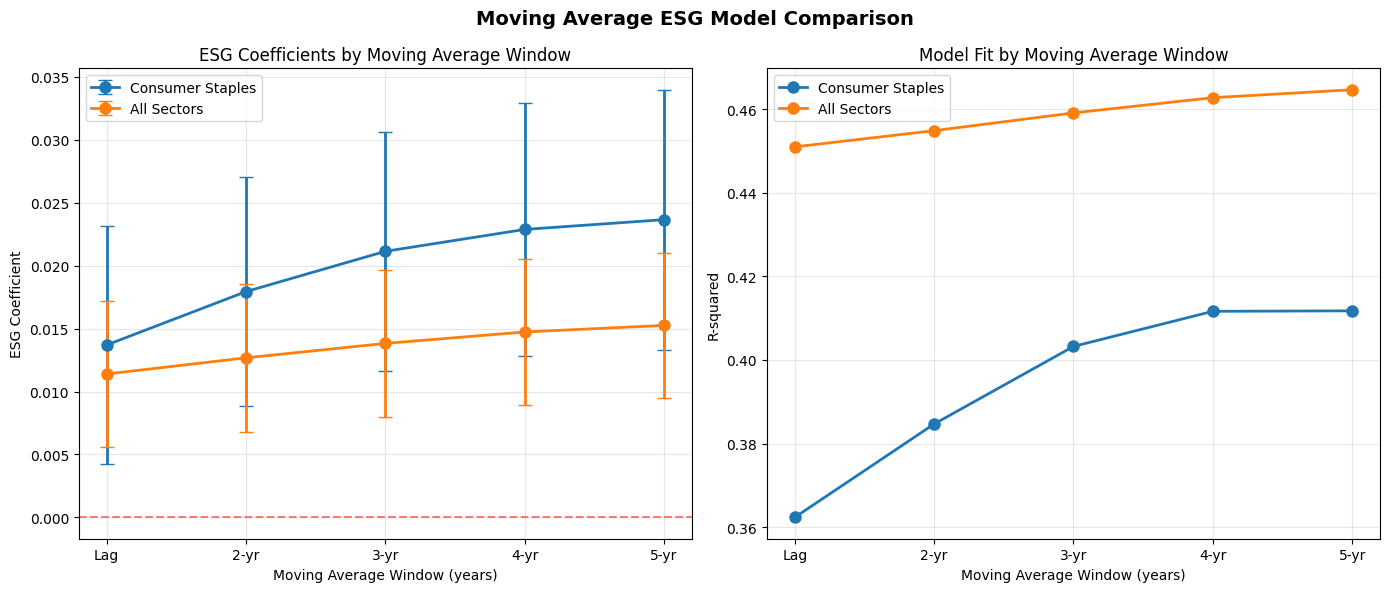

✓ Plot saved to: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_esg_outputs/coefficient_trends.png

ANALYSIS COMPLETE

All outputs saved to: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_esg_outputs
Main Excel file: /content/drive/MyDrive/Colab Notebooks/FTSE Data/moving_avg_esg_outputs/moving_avg_esg_results_20260214_111329.xlsx


In [3]:
# moving_average_esg_model.py
"""
Moving Average ESG Model Analysis
- Simple lag (t-1)
- Moving averages: 1-2 years, 1-3 years, 1-4 years, 1-5 years
With comprehensive output including equations and Excel export
"""

# ============================================================================
# SETUP AND IMPORTS
# ============================================================================
from google.colab import drive
drive.mount('/content/drive')

!pip install -q linearmodels pandas numpy matplotlib seaborn statsmodels openpyxl

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from linearmodels.panel import PanelOLS
import warnings
from datetime import datetime
warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================
class Config:
    """Configuration parameters for moving average ESG analysis"""
    PROJECT_DIR = '/content/drive/MyDrive/Colab Notebooks/FTSE Data'
    DATA_PATH = os.path.join(PROJECT_DIR, 'FTSE data.xlsx')
    OUTPUT_DIR = os.path.join(PROJECT_DIR, 'moving_avg_esg_outputs')

    # Using aggregate ESG
    ESG_COMPONENTS = ['ESG']
    CONTROL_VARS = ['ROA', 'Size', 'Leverage']

    # Moving average windows to test
    MA_WINDOWS = [1, 2, 3, 4, 5]  # 1 = simple lag, 2 = avg of t-1,t-2, etc.

    # Consumer Staples firms
    CONSUMER_STAPLES_FIRMS = [
        'Associated British Foods', 'British American Tobacco', 'Coca Cola HBC AG',
        'Diageo', 'J. Sainsbury', 'Reckitt Benckiser', 'Tesco', 'Unilever', 'Haleon Plc'
    ]

# ============================================================================
# DATA LOADER
# ============================================================================
class DataLoader:
    """Load and prepare data with aggregate ESG score"""

    def __init__(self, config):
        self.config = config
        self.df = None
        self.df_cs = None
        self.df_all = None

    def load_and_prepare_data(self):
        """Load data and create aggregate ESG score"""
        print("Loading and preparing data...")

        # 1. Load data
        self.df = pd.read_excel(self.config.DATA_PATH)
        self.df = self.df.set_index(['Firm', 'Year']).sort_index()
        self.df = self.df.rename(columns={"Tobin's Q": "Tobin_Q"})

        # 2. Create aggregate ESG score
        if all(col in self.df.columns for col in ['E', 'S', 'G']):
            self.df['ESG'] = self.df[['E', 'S', 'G']].mean(axis=1)
            print("✓ Created aggregate ESG score from E, S, G components")
        else:
            if 'ESG' not in self.df.columns:
                raise ValueError("No ESG score available in data")

        # 3. Create control variables
        self.df['Size'] = np.log(self.df['Total Assets'])
        self.df['Leverage'] = self.df['Total Liabilities'] / self.df['Total Assets']
        self.df['Tobin_Q_log'] = np.log(self.df['Tobin_Q'] + 0.001)

        # 4. Create lagged ESG variables (for moving averages)
        for lag in range(1, max(self.config.MA_WINDOWS) + 1):
            self.df[f'ESG_lag{lag}'] = self.df.groupby(level=0)['ESG'].shift(lag)

        # 5. Create moving averages
        for window in self.config.MA_WINDOWS:
            if window == 1:
                self.df['ESG_MA1'] = self.df['ESG_lag1']  # Simple lag
            else:
                # Sum the relevant lags and divide by window
                lag_cols = [f'ESG_lag{lag}' for lag in range(1, window + 1)]
                self.df[f'ESG_MA{window}'] = self.df[lag_cols].mean(axis=1)

        # 6. Create lagged control variables
        self.df['ROA_lag'] = self.df.groupby(level=0)['ROA'].shift(1)
        self.df['Size_lag'] = self.df.groupby(level=0)['Size'].shift(1)
        self.df['Leverage_lag'] = self.df.groupby(level=0)['Leverage'].shift(1)

        # 7. Create sector variable
        sectors = []
        for firm in self.df.index.get_level_values(0):
            if firm in self.config.CONSUMER_STAPLES_FIRMS:
                sectors.append('Consumer Staples')
            else:
                sectors.append('Other')

        self.df['Sector'] = sectors
        self.df['ConsumerStaples'] = (self.df['Sector'] == 'Consumer Staples').astype(int)

        # 8. Create datasets
        self.df_cs = self.df[self.df['ConsumerStaples'] == 1].copy()
        self.df_all = self.df.copy()

        print(f"✓ Total observations: {len(self.df)}")
        print(f"✓ Consumer Staples: {len(self.df_cs)} observations")
        print(f"✓ All sectors: {len(self.df_all)} observations")

        return self.df, self.df_cs, self.df_all

# ============================================================================
# MOVING AVERAGE ANALYZER
# ============================================================================
class MovingAverageAnalyzer:
    """Run moving average regressions for ESG scores"""

    def __init__(self, config):
        self.config = config
        self.loader = DataLoader(config)
        self.results = {}
        self.equations = {}

    def run_all_models(self):
        """Run all moving average models"""
        print("\n" + "="*80)
        print("MOVING AVERAGE ESG MODEL ANALYSIS")
        print("="*80)

        # Load data
        df, df_cs, df_all = self.loader.load_and_prepare_data()

        # Run models for each moving average window
        for window in self.config.MA_WINDOWS:
            ma_var = f'ESG_MA{window}'
            window_desc = f"{'Simple Lag (t-1)' if window == 1 else f'Moving Average {window} years (t-1 to t-{window})'}"

            print(f"\n{'='*60}")
            print(f"MODEL: {window_desc}")
            print(f"{'='*60}")

            # Run for both sectors
            for sector_code, sector_df, sector_name in [
                ('cs', df_cs, 'Consumer Staples Only'),
                ('all', df_all, 'All Sectors')
            ]:
                self._run_single_model(sector_df, ma_var, window, sector_code, sector_name)

    def _run_single_model(self, df, ma_var, window, sector_code, sector_name):
        """Run a single moving average regression"""
        print(f"\n--- {sector_name} ---")

        # Prepare variables
        if sector_code == 'all':
            all_vars = [ma_var] + self.config.CONTROL_VARS + ['ConsumerStaples', 'Tobin_Q']
        else:
            all_vars = [ma_var] + self.config.CONTROL_VARS + ['Tobin_Q']

        # Clean data
        df_clean = df.dropna(subset=all_vars)

        if len(df_clean) < 10:
            print(f"⚠ Insufficient data: {len(df_clean)} observations")
            return None

        print(f"Observations: {len(df_clean)}")
        print(f"Firms: {df_clean.index.get_level_values(0).nunique()}")

        # Prepare regression
        y = df_clean['Tobin_Q']
        X_vars = [ma_var] + self.config.CONTROL_VARS
        if sector_code == 'all':
            X_vars = X_vars + ['ConsumerStaples']

        X = df_clean[X_vars]
        X = pd.concat([pd.Series(1, index=X.index, name='const'), X], axis=1)

        # Run regression
        try:
            model = PanelOLS(y, X, entity_effects=False, time_effects=False)
            results = model.fit(cov_type='robust')

            # Store results
            key = f"MA{window}_{sector_code}"
            self.results[key] = {
                'results': results,
                'window': window,
                'sector': sector_code,
                'sector_name': sector_name,
                'ma_var': ma_var,
                'nobs': results.nobs,
                'r2': results.rsquared,
                'data': df_clean
            }

            # Generate and store equation
            equation = self._generate_equation(results, ma_var, window, sector_name)
            self.equations[key] = equation

            # Print results
            self._print_results(results, ma_var, window, sector_name)
            self._print_regression_table(results, f"MA{window} - {sector_name}")
            print(f"\nEquation:\n{equation}")

            return results

        except Exception as e:
            print(f"Error running model: {e}")
            return None

    def _generate_equation(self, results, ma_var, window, sector_name):
        """Generate regression equation as string"""
        # Start with dependent variable
        equation = f"Tobin's Q = "

        # Add constant
        if 'const' in results.params:
            const_val = results.params['const']
            equation += f"{const_val:.4f}"

        # Add ESG moving average
        if ma_var in results.params:
            coeff = results.params[ma_var]
            sign = " + " if coeff >= 0 else " - "
            equation += f"{sign}{abs(coeff):.4f} × ESG_MA{window}"

        # Add control variables
        for var in self.config.CONTROL_VARS:
            if var in results.params:
                coeff = results.params[var]
                sign = " + " if coeff >= 0 else " - "
                equation += f"{sign}{abs(coeff):.4f} × {var}"

        # Add sector dummy if present
        if 'ConsumerStaples' in results.params:
            coeff = results.params['ConsumerStaples']
            sign = " + " if coeff >= 0 else " - "
            equation += f"{sign}{abs(coeff):.4f} × ConsumerStaples"

        # Add model statistics
        equation += f"\n\nR² = {results.rsquared:.4f}"
        equation += f"\nN = {results.nobs}"
        if hasattr(results, 'f_statistic'):
            equation += f"\nF({results.f_statistic.df_num:.0f}, {results.f_statistic.df_denom:.0f}) = {results.f_statistic.stat:.4f} (p={results.f_statistic.pval:.4f})"

        return equation

    def _print_results(self, results, ma_var, window, sector_name):
        """Print summary results"""
        print(f"\nRESULTS: Moving Average {window} years - {sector_name}")
        print("-" * 60)
        print(f"R-squared: {results.rsquared:.4f}")
        print(f"Observations: {results.nobs}")

        if hasattr(results, 'f_statistic'):
            print(f"F-statistic: {results.f_statistic.stat:.4f} (p={results.f_statistic.pval:.4f})")

        print(f"\nESG_MA{window} Coefficient:")
        if ma_var in results.params:
            coeff = results.params[ma_var]
            pval = results.pvalues.get(ma_var, 1.0)
            sig = "***" if pval < 0.01 else "**" if pval < 0.05 else "*" if pval < 0.10 else ""
            print(f"  {coeff:.4f}{sig} (p={pval:.4f})")

    def _print_regression_table(self, results, title):
        """Print formatted regression table"""
        print("\n" + "="*70)
        print(f"REGRESSION TABLE: {title}")
        print("="*70)
        print(f"{'Variable':<20} {'Coefficient':>12} {'Std.Error':>12} {'t-stat':>10} {'p-value':>10} {'Sig':>6}")
        print("-"*70)

        # Print all variables
        for var in sorted(results.params.index):
            coeff = results.params[var]
            std_err = results.std_errors.get(var, np.nan) if hasattr(results, 'std_errors') else np.nan
            t_stat = results.tstats.get(var, np.nan) if hasattr(results, 'tstats') else np.nan
            pval = results.pvalues.get(var, np.nan)

            # Determine significance
            if pval < 0.01:
                sig = '***'
            elif pval < 0.05:
                sig = '**'
            elif pval < 0.10:
                sig = '*'
            else:
                sig = ''

            print(f"{var:<20} {coeff:>12.4f} {std_err:>12.4f} {t_stat:>10.4f} {pval:>10.4f} {sig:>6}")

        print("-"*70)
        print(f"R-squared: {results.rsquared:.4f}")
        print(f"Observations: {results.nobs}")
        print("="*70)
        print("Significance codes: *** p<0.01, ** p<0.05, * p<0.10")

    def create_comparison_table(self):
        """Create comparison table across all moving average windows"""
        comparison_data = []

        for key, model_info in self.results.items():
            results = model_info['results']
            window = model_info['window']
            ma_var = model_info['ma_var']

            row = {
                'Moving_Average_Window': f"{'Simple Lag' if window == 1 else f'{window}-Year MA'}",
                'Window_Years': window,
                'Sector': model_info['sector_name'],
                'Observations': results.nobs,
                'R_squared': results.rsquared,
                'R_squared_adj': getattr(results, 'rsquared_adj', np.nan),
            }

            # Add ESG coefficient
            if ma_var in results.params:
                row['ESG_Coefficient'] = results.params[ma_var]
                row['ESG_P_value'] = results.pvalues.get(ma_var, np.nan)
                row['ESG_Significance'] = self._get_significance_stars(results.pvalues.get(ma_var, np.nan))

            # Add F-statistic
            if hasattr(results, 'f_statistic'):
                row['F_statistic'] = results.f_statistic.stat
                row['F_p_value'] = results.f_statistic.pval

            # Add control variable coefficients
            for var in self.config.CONTROL_VARS:
                if var in results.params:
                    row[f'{var}_coeff'] = results.params[var]
                    row[f'{var}_pval'] = results.pvalues.get(var, np.nan)

            comparison_data.append(row)

        return pd.DataFrame(comparison_data)

    def _get_significance_stars(self, p_value):
        """Return significance stars based on p-value"""
        if p_value < 0.01:
            return '***'
        elif p_value < 0.05:
            return '**'
        elif p_value < 0.10:
            return '*'
        else:
            return ''

# ============================================================================
# RESULTS EXPORTER
# ============================================================================
class ResultsExporter:
    """Export results to Excel"""

    def __init__(self, config, analyzer):
        self.config = config
        self.analyzer = analyzer
        os.makedirs(config.OUTPUT_DIR, exist_ok=True)

    def export_to_excel(self):
        """Export all results to Excel with multiple sheets"""
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        excel_path = os.path.join(self.config.OUTPUT_DIR, f'moving_avg_esg_results_{timestamp}.xlsx')

        with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
            # Sheet 1: Summary comparison
            comparison_df = self.analyzer.create_comparison_table()
            comparison_df.to_excel(writer, sheet_name='Summary_Comparison', index=False)

            # Sheet 2: All equations
            equations_data = []
            for key, equation in self.analyzer.equations.items():
                model_info = self.analyzer.results[key]
                equations_data.append({
                    'Model': f"{'Simple Lag' if model_info['window'] == 1 else f'MA{model_info['window']}'} - {model_info['sector_name']}",
                    'Window': model_info['window'],
                    'Sector': model_info['sector_name'],
                    'Equation': equation
                })
            pd.DataFrame(equations_data).to_excel(writer, sheet_name='Equations', index=False)

            # Sheets for each moving average window
            for window in self.config.MA_WINDOWS:
                window_name = f"Simple_Lag" if window == 1 else f"MA_{window}yr"

                for sector_code in ['cs', 'all']:
                    key = f"MA{window}_{sector_code}"
                    if key in self.analyzer.results:
                        model_info = self.analyzer.results[key]
                        results = model_info['results']

                        # Create regression table
                        table_data = []
                        for var in results.params.index:
                            row = {
                                'Variable': var,
                                'Coefficient': results.params[var],
                                'Std_Error': results.std_errors.get(var, np.nan) if hasattr(results, 'std_errors') else np.nan,
                                't_stat': results.tstats.get(var, np.nan) if hasattr(results, 'tstats') else np.nan,
                                'P_value': results.pvalues.get(var, np.nan),
                                'Significance': self.analyzer._get_significance_stars(results.pvalues.get(var, np.nan))
                            }
                            table_data.append(row)

                        # Add model statistics
                        table_data.append({'Variable': 'R-squared', 'Coefficient': results.rsquared})
                        table_data.append({'Variable': 'Observations', 'Coefficient': results.nobs})
                        if hasattr(results, 'f_statistic'):
                            table_data.append({'Variable': 'F-statistic', 'Coefficient': results.f_statistic.stat})
                            table_data.append({'Variable': 'F_p_value', 'Coefficient': results.f_statistic.pval})

                        df_table = pd.DataFrame(table_data)
                        sheet_name = f"{window_name}_{model_info['sector_name'][:10]}"
                        df_table.to_excel(writer, sheet_name=sheet_name, index=False)

            # Sheet 3: Coefficient trends
            trends_data = []
            for window in self.config.MA_WINDOWS:
                for sector_code in ['cs', 'all']:
                    key = f"MA{window}_{sector_code}"
                    if key in self.analyzer.results:
                        model_info = self.analyzer.results[key]
                        results = model_info['results']
                        ma_var = model_info['ma_var']

                        if ma_var in results.params:
                            trends_data.append({
                                'Window': window,
                                'Window_Desc': 'Simple Lag' if window == 1 else f'{window}-Year MA',
                                'Sector': model_info['sector_name'],
                                'ESG_Coefficient': results.params[ma_var],
                                'ESG_P_value': results.pvalues.get(ma_var, np.nan),
                                'R_squared': results.rsquared
                            })

            pd.DataFrame(trends_data).to_excel(writer, sheet_name='Coefficient_Trends', index=False)

        print(f"\n✓ Results exported to: {excel_path}")
        return excel_path

    def plot_coefficient_trends(self):
        """Plot how ESG coefficients change with moving average window"""
        trends_data = []
        for window in self.config.MA_WINDOWS:
            for sector_code, sector_label in [('cs', 'Consumer Staples'), ('all', 'All Sectors')]:
                key = f"MA{window}_{sector_code}"
                if key in self.analyzer.results:
                    model_info = self.analyzer.results[key]
                    results = model_info['results']
                    ma_var = model_info['ma_var']

                    if ma_var in results.params:
                        trends_data.append({
                            'Window': window,
                            'Sector': sector_label,
                            'Coefficient': results.params[ma_var],
                            'CI_Lower': results.params[ma_var] - 1.96 * results.std_errors.get(ma_var, 0),
                            'CI_Upper': results.params[ma_var] + 1.96 * results.std_errors.get(ma_var, 0),
                            'P_value': results.pvalues.get(ma_var, 1.0)
                        })

        if trends_data:
            df_trends = pd.DataFrame(trends_data)

            fig, axes = plt.subplots(1, 2, figsize=(14, 6))

            # Plot 1: Coefficient values with confidence intervals
            for sector in df_trends['Sector'].unique():
                sector_data = df_trends[df_trends['Sector'] == sector]
                axes[0].errorbar(sector_data['Window'], sector_data['Coefficient'],
                               yerr=[sector_data['Coefficient'] - sector_data['CI_Lower'],
                                     sector_data['CI_Upper'] - sector_data['Coefficient']],
                               fmt='o-', capsize=5, linewidth=2, markersize=8,
                               label=sector)

            axes[0].axhline(y=0, color='r', linestyle='--', alpha=0.5)
            axes[0].set_xlabel('Moving Average Window (years)')
            axes[0].set_ylabel('ESG Coefficient')
            axes[0].set_title('ESG Coefficients by Moving Average Window')
            axes[0].set_xticks(self.config.MA_WINDOWS)
            axes[0].set_xticklabels(['Lag' if w==1 else f'{w}-yr' for w in self.config.MA_WINDOWS])
            axes[0].legend()
            axes[0].grid(True, alpha=0.3)

            # Plot 2: R-squared values
            for sector in df_trends['Sector'].unique():
                sector_data = df_trends[df_trends['Sector'] == sector]
                axes[1].plot(sector_data['Window'],
                           [self.analyzer.results[f"MA{w}_{'cs' if sector=='Consumer Staples' else 'all'}"]['r2']
                            for w in sector_data['Window']],
                           'o-', linewidth=2, markersize=8, label=sector)

            axes[1].set_xlabel('Moving Average Window (years)')
            axes[1].set_ylabel('R-squared')
            axes[1].set_title('Model Fit by Moving Average Window')
            axes[1].set_xticks(self.config.MA_WINDOWS)
            axes[1].set_xticklabels(['Lag' if w==1 else f'{w}-yr' for w in self.config.MA_WINDOWS])
            axes[1].legend()
            axes[1].grid(True, alpha=0.3)

            plt.suptitle('Moving Average ESG Model Comparison', fontsize=14, fontweight='bold')
            plt.tight_layout()

            # Save plot
            plot_path = os.path.join(self.config.OUTPUT_DIR, 'coefficient_trends.png')
            plt.savefig(plot_path, dpi=300, bbox_inches='tight')
            plt.show()

            print(f"✓ Plot saved to: {plot_path}")

# ============================================================================
# MAIN EXECUTION
# ============================================================================
def main():
    """Main execution function"""
    print("\n" + "="*80)
    print("MOVING AVERAGE ESG MODEL ANALYSIS")
    print("="*80)
    print("\nModels to be estimated:")
    print("1. Simple Lag (t-1 only)")
    print("2. Moving Average 1-2 years (avg of t-1 and t-2)")
    print("3. Moving Average 1-3 years (avg of t-1, t-2, t-3)")
    print("4. Moving Average 1-4 years (avg of t-1 through t-4)")
    print("5. Moving Average 1-5 years (avg of t-1 through t-5)")

    # Initialize
    config = Config()
    analyzer = MovingAverageAnalyzer(config)

    # Run all models
    analyzer.run_all_models()

    # Create and print comparison table
    print("\n" + "="*80)
    print("MODEL COMPARISON SUMMARY")
    print("="*80)
    comparison_df = analyzer.create_comparison_table()
    print(comparison_df.to_string(index=False))

    # Export results
    exporter = ResultsExporter(config, analyzer)
    excel_path = exporter.export_to_excel()
    exporter.plot_coefficient_trends()

    print("\n" + "="*80)
    print("ANALYSIS COMPLETE")
    print("="*80)
    print(f"\nAll outputs saved to: {config.OUTPUT_DIR}")
    print(f"Main Excel file: {excel_path}")

    return analyzer, comparison_df

# ============================================================================
# EXECUTION
# ============================================================================
if __name__ == "__main__":
    analyzer, comparison_df = main()